
GENERIC ORACLE SELECTION - DEUTSCH ALGORITHM

FUNCTION : constant_0
----------------------------------------------------------------------
     ┌───┐     ┌─────────────┐┌───┐
q_0: ┤ H ├─────┤0            ├┤ H ├
     ├───┤┌───┐│  constant_0 │└───┘
q_1: ┤ X ├┤ H ├┤1            ├─────
     └───┘└───┘└─────────────┘     

MEASUREMENT
0 count                 : 1000
1 count                 : 0
P(0)                    : 1.0000
P(1)                    : 0.0000
Deutsch output          : 0
Classification          : CONSTANT

FUNCTION : constant_1
----------------------------------------------------------------------
     ┌───┐     ┌─────────────┐┌───┐
q_0: ┤ H ├─────┤0            ├┤ H ├
     ├───┤┌───┐│  constant_1 │└───┘
q_1: ┤ X ├┤ H ├┤1            ├─────
     └───┘└───┘└─────────────┘     

MEASUREMENT
0 count                 : 1000
1 count                 : 0
P(0)                    : 1.0000
P(1)                    : 0.0000
Deutsch output          : 0
Classification          : CONSTANT

FUN

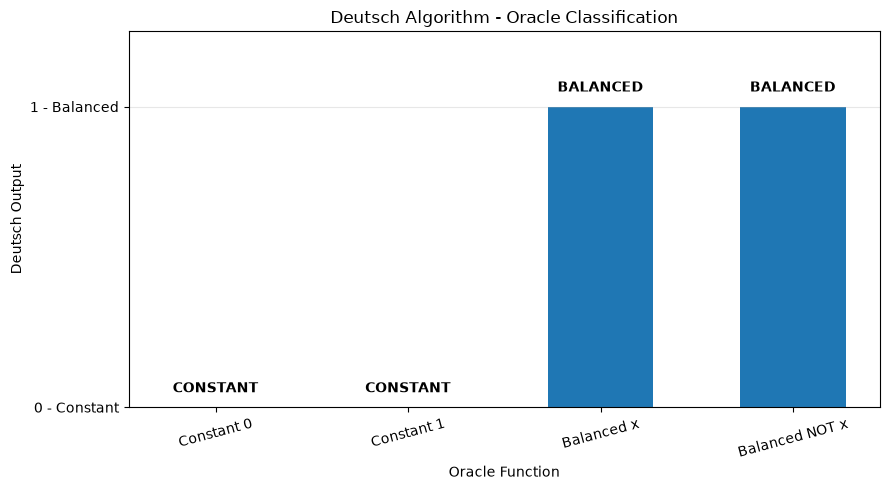

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1000

# ---------------------------------------------------------
# GENERIC ORACLE FUNCTION
# ---------------------------------------------------------

def create_oracle(function_type):
    oracle = QuantumCircuit(2, name=function_type)

    if function_type == "constant_0":
        # f(x) = 0
        pass

    elif function_type == "constant_1":
        # f(x) = 1
        oracle.x(1)

    elif function_type == "balanced_x":
        # f(x) = x
        oracle.cx(0, 1)

    elif function_type == "balanced_not_x":
        # f(x) = NOT x
        oracle.x(1)
        oracle.cx(0, 1)

    else:
        raise ValueError("Invalid function type")

    return oracle.to_gate()

# ---------------------------------------------------------
# DEUTSCH ALGORITHM
# ---------------------------------------------------------

def run_deutsch(function_type):
    qc = QuantumCircuit(2)

    # Control qubit -> |+>
    qc.h(0)

    # Target qubit -> |->
    qc.x(1)
    qc.h(1)

    # Dynamically selected oracle
    oracle = create_oracle(function_type)
    qc.append(oracle, [0, 1])

    # Final Hadamard
    qc.h(0)

    # Statevector
    state = Statevector.from_instruction(qc)
    probabilities = state.probabilities()

    # Probability of control qubit 0 and 1
    p0 = sum(
        probabilities[i]
        for i in range(len(probabilities))
        if (i & 1) == 0
    )

    p1 = 1 - p0

    # Simulated measurement
    rng = np.random.default_rng(42)

    samples = rng.choice(
        [0, 1],
        size=SHOTS,
        p=[p0, p1]
    )

    count0 = int(np.sum(samples == 0))
    count1 = int(np.sum(samples == 1))

    measured_p0 = count0 / SHOTS
    measured_p1 = count1 / SHOTS

    # Classification
    if measured_p0 > measured_p1:
        classification = "CONSTANT"
        output = 0
    else:
        classification = "BALANCED"
        output = 1

    return (
        qc,
        count0,
        count1,
        measured_p0,
        measured_p1,
        output,
        classification
    )

# ---------------------------------------------------------
# TEST ALL FOUR BOOLEAN FUNCTIONS
# ---------------------------------------------------------

functions = [
    "constant_0",
    "constant_1",
    "balanced_x",
    "balanced_not_x"
]

results = []

print("\nGENERIC ORACLE SELECTION - DEUTSCH ALGORITHM")
print("=" * 70)

for function_type in functions:

    (
        qc,
        count0,
        count1,
        p0,
        p1,
        output,
        classification
    ) = run_deutsch(function_type)

    results.append({
        "function": function_type,
        "p0": p0,
        "p1": p1,
        "output": output,
        "classification": classification
    })

    print("\nFUNCTION :", function_type)
    print("-" * 70)

    print(qc.draw())

    print("\nMEASUREMENT")
    print(f"0 count                 : {count0}")
    print(f"1 count                 : {count1}")
    print(f"P(0)                    : {p0:.4f}")
    print(f"P(1)                    : {p1:.4f}")
    print(f"Deutsch output          : {output}")
    print(f"Classification          : {classification}")

# ---------------------------------------------------------
# SUMMARY TABLE
# ---------------------------------------------------------

print("\n\nFINAL CLASSIFICATION SUMMARY")
print("=" * 70)

print(
    f"{'Function':<20}"
    f"{'Output':<10}"
    f"{'P(0)':<12}"
    f"{'P(1)':<12}"
    f"{'Classification'}"
)

print("-" * 70)

for result in results:
    print(
        f"{result['function']:<20}"
        f"{result['output']:<10}"
        f"{result['p0']:<12.4f}"
        f"{result['p1']:<12.4f}"
        f"{result['classification']}"
    )

print("\nAll four oracle types tested successfully.")

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

function_names = [
    "Constant 0",
    "Constant 1",
    "Balanced x",
    "Balanced NOT x"
]

outputs = [result["output"] for result in results]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    function_names,
    outputs,
    width=0.55
)

ax.set_title(
    "Deutsch Algorithm - Oracle Classification"
)

ax.set_xlabel("Oracle Function")
ax.set_ylabel("Deutsch Output")

ax.set_ylim(0, 1.25)

ax.set_yticks([0, 1])
ax.set_yticklabels([
    "0 - Constant",
    "1 - Balanced"
])

for bar, value in zip(bars, outputs):
    label = "CONSTANT" if value == 0 else "BALANCED"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        label,
        ha="center",
        fontweight="bold"
    )

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()